# Experiment 4: Comparative Study of Deep CNN Architectures Using Transfer Learning
**CS3807 – Deep Learning Laboratory**

**Model used for Transfer Learning:** VGG16 (pretrained on ImageNet)
**Dataset:** CIFAR-10


In [ ]:
# !pip install --upgrade tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 12.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


_available_fonts = {f.name for f in fm.fontManager.ttflist}
_preferred = ['Times New Roman', 'Liberation Serif', 'Nimbus Roman', 'DejaVu Serif']
FONT_FAMILY = next((f for f in _preferred if f in _available_fonts), 'serif')
print(f"Using font family for plots: {FONT_FAMILY}")

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelweight'] = 'bold'   # bold x/y axis LABELS
plt.rcParams['axes.titleweight'] = 'bold'   # bold plot titles
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.format'] = 'eps'


def bold_ticks(ax=None):
    """Bold the x and y tick numbers/labels on the given axis (rcParams can't do this)."""
    if ax is None:
        ax = plt.gca()
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily(FONT_FAMILY)


def bold_legend(ax=None, legend_obj=None):
    """Bold the legend text on the given axis, or on an explicit legend object."""
    leg = legend_obj
    if leg is None:
        ax = ax if ax is not None else plt.gca()
        leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontweight('bold')
            text.set_fontfamily(FONT_FAMILY)


Using font family for plots: Liberation Serif


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

class_names = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']


## Task 1: Dataset Preparation

In [ ]:
import os

os.listdir("/content")

['.config', '.ipynb_checkpoints', 'cifar-10-batches-py', 'sample_data']

In [ ]:
os.listdir("cifar-10-batches-py")

['data_batch_1',
 'data_batch_3',
 'test_batch',
 '.ipynb_checkpoints',
 'data_batch_4',
 'data_batch_2',
 'batches.meta',
 'data_batch_5']

In [ ]:
import pickle
import numpy as np
import os


def load_batch(filename):

    with open(filename,'rb') as f:
        batch=pickle.load(f,encoding='bytes')

    return batch[b'data'], batch[b'labels']


x_train=[]
y_train=[]

folder="/content/cifar-10-batches-py"


for i in range(1,6):

    data,labels=load_batch(
        f"{folder}/data_batch_{i}"
    )

    x_train.append(data)
    y_train.extend(labels)


x_train=np.concatenate(x_train)

y_train=np.array(y_train)
x_test,y_test = load_batch(
    f"{folder}/test_batch"
)


y_test=np.array(y_test)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)


(50000, 3072)
(50000,)
(10000, 3072)
(10000,)


In [ ]:
x_train=x_train.reshape(-1,3,32,32)

x_train=np.transpose(
    x_train,
    (0,2,3,1)
)

x_test=x_test.reshape(
    -1,3,32,32
)
x_test=np.transpose(
    x_test,
    (0,2,3,1)
)

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
# (x_train, y_train), (x_test, y_test) = cifar10.load_data()

# x_train = x_train.astype('float32') / 255.0
# x_test = x_test.astype('float32') / 255.0

# y_train_cat = to_categorical(y_train, 10)
# y_test_cat = to_categorical(y_test, 10)


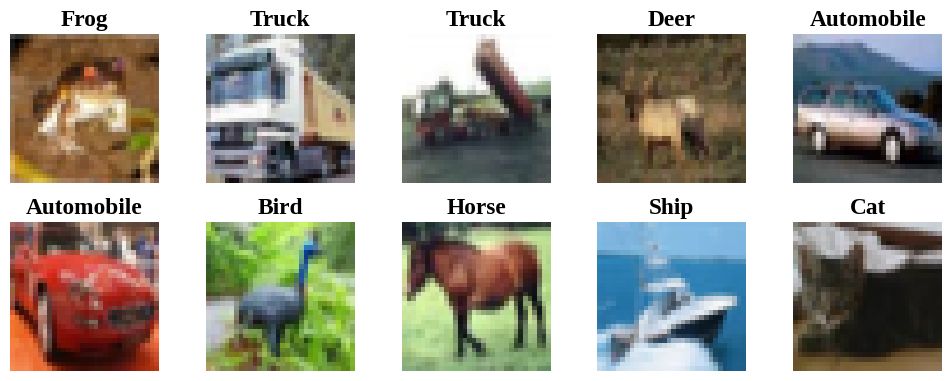

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)


Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Training labels shape: (50000,)
Testing labels shape: (10000,)


**Inference:** The sample images confirm that CIFAR-10 has been loaded and normalized correctly, showing 32x32 color images spread across 10 visually distinct classes. The training set contains 50,000 images and the test set contains 10,000 images, matching the dataset description in the manual.

## Task 2: Transfer Learning Setup (VGG16)

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # freeze convolutional base

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Task 3: Model Training (Frozen Base)

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start_time = time.time()
history1 = model.fit(x_train, y_train_cat,
                      validation_data=(x_test, y_test_cat),
                      batch_size=32,
                      epochs=10)
train_time1 = time.time() - start_time

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.5325 - loss: 1.3398 - val_accuracy: 0.5598 - val_loss: 1.2544
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5918 - loss: 1.1700 - val_accuracy: 0.5831 - val_loss: 1.1906
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6129 - loss: 1.1021 - val_accuracy: 0.5915 - val_loss: 1.1603
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6309 - loss: 1.0531 - val_accuracy: 0.6018 - val_loss: 1.1350
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6448 - loss: 1.0115 - val_accuracy: 0.6049 - val_loss: 1.1280
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6596 - loss: 0.9707 - val_accuracy: 0.6143 - val_loss: 1.1078
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6702 - loss: 0.9356 - val_accuracy: 0.6157 - val_loss: 1.1044
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6794 - loss: 

## Task 4: Fine Tuning

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-4]:      # unfreeze only the last conv block
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start_time = time.time()
history2 = model.fit(x_train, y_train_cat,
                      validation_data=(x_test, y_test_cat),
                      batch_size=32,
                      epochs=5)
train_time2 = time.time() - start_time
total_train_time = train_time1 + train_time2


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.6473 - loss: 1.0096 - val_accuracy: 0.6757 - val_loss: 0.9232
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7334 - loss: 0.7586 - val_accuracy: 0.7019 - val_loss: 0.8663
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7779 - loss: 0.6259 - val_accuracy: 0.7219 - val_loss: 0.8368
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8164 - loss: 0.5095 - val_accuracy: 0.7303 - val_loss: 0.8293
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8505 - loss: 0.4083 - val_accuracy: 0.7396 - val_loss: 0.8538


In [ ]:
print("Validation Accuracy before fine tuning:", history1.history['val_accuracy'][-1])
print("Validation Accuracy after fine tuning:", history2.history['val_accuracy'][-1])


Validation Accuracy before fine tuning: 0.6140999794006348
Validation Accuracy after fine tuning: 0.7396000027656555


## Mandatory Plots: Training/Validation Accuracy and Loss

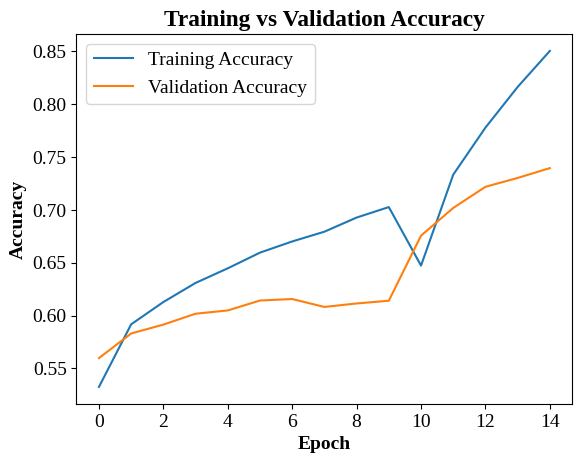

In [ ]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


**Inference:** Training accuracy is expected to rise steadily as the classifier head learns from the frozen VGG16 features, with a further boost once fine tuning unfreezes the last convolution block. Validation accuracy should track training accuracy closely; a widening gap between the two curves after fine tuning would indicate the onset of overfitting.

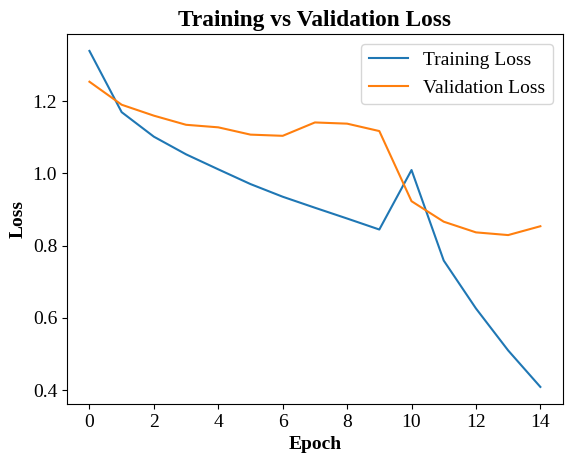

In [ ]:
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


**Inference:** Both training and validation loss are expected to fall as the model trains, with a further drop during fine tuning as pretrained ImageNet features adapt to CIFAR-10. If validation loss starts rising while training loss keeps falling during fine tuning, it signals overfitting.

## Task 5: Model Evaluation

In [ ]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

test_loss, test_acc = model.evaluate(x_test, y_test_cat)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("Test Accuracy:", test_acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print()
print(classification_report(y_true, y_pred, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7396 - loss: 0.8538
Test Accuracy: 0.7396000027656555
Precision: 0.7558722005254981
Recall: 0.7396
F1-score: 0.7420514344743722

              precision    recall  f1-score   support

    Airplane       0.77      0.85      0.81      1000
  Automobile       0.88      0.80      0.83      1000
        Bird       0.73      0.69      0.71      1000
         Cat       0.47      0.72      0.57      1000
        Deer       0.67      0.72      0.70      1000
         Dog       0.70      0.48      0.57      1000
        Frog       0.82      0.72      0.77      1000
       Horse       0.86      0.75      0.80      1000
        Ship       0.84      0.87      0.86      1000
       Truck       0.82      0.80      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.76      0.74      0.74     10000
weighted avg       0.76      0.74      0.74     10000



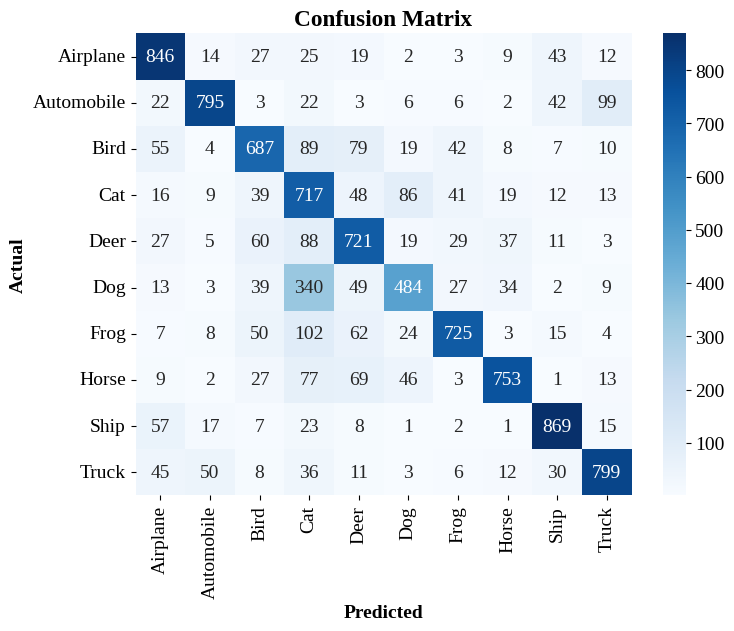

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


**Inference:** The diagonal cells show correctly classified images for each class, while off-diagonal cells reveal which classes are confused with one another. Visually similar categories such as Cat/Dog or Automobile/Truck are typically confused more often than visually distinct ones such as Airplane or Ship.

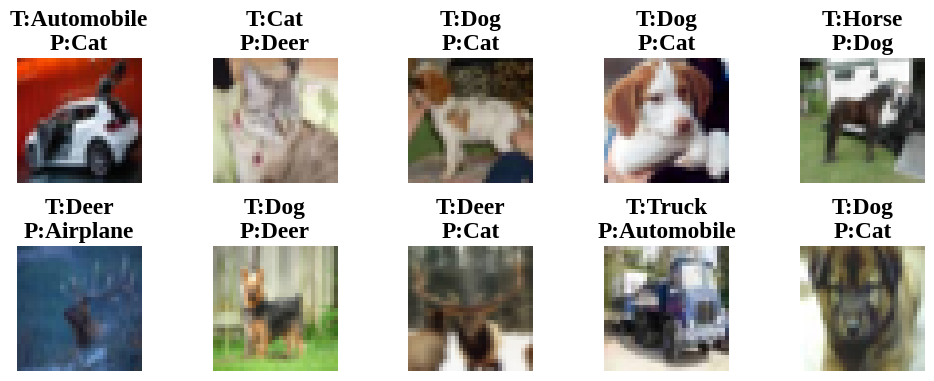

In [ ]:
misclassified_idx = np.where(y_pred != y_true)[0][:10]

plt.figure(figsize=(10, 4))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


**Inference:** Most misclassified images belong to visually ambiguous or low-resolution samples where fine-grained details are hard to capture at 32x32 pixels. Errors tend to occur between semantically related classes (e.g., Cat vs Dog, Deer vs Horse), reflecting genuine visual similarity rather than random model failure.

## Hyperparameter Study

In [ ]:
import itertools
import pandas as pd
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from tqdm.notebook import tqdm  # Use 'from tqdm import tqdm' if running in a standard Python script

# Define hyperparameter grid options
learning_rates = [0.001, 0.0001]
batch_sizes = [16, 32, 64]
epochs_list = [10, 20]
optimizers = ['Adam', 'SGD']
dense_units_list = [128, 256]
frozen_layers_list = ['All', 'Partial']

# Generate all 96 parameter combinations
param_grid = list(
    itertools.product(
        learning_rates,
        batch_sizes,
        epochs_list,
        optimizers,
        dense_units_list,
        frozen_layers_list,
    )
)

hp_results = []

# Wrap param_grid with tqdm for a visual progress bar
for lr, batch_size, epochs, opt_name, dense_units, frozen in tqdm(
    param_grid, desc='Hyperparameter Tuning Progress'
):
    # 1. Base Model Setup
    base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

    # 2. Frozen Layers Logic
    if frozen == 'All':
        base.trainable = False
    elif frozen == 'Partial':
        base.trainable = True
        for layer in base.layers:
            if 'block5' not in layer.name:
                layer.trainable = False

    # 3. Top Architecture
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(dense_units, activation='relu')(x)
    out = Dense(10, activation='softmax')(x)
    hp_model = Model(inputs=base.input, outputs=out)

    # 4. Optimizer Selection
    optimizer = Adam(learning_rate=lr) if opt_name == 'Adam' else SGD(learning_rate=lr)

    # 5. Compile
    hp_model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    # 6. Fit Model
    h = hp_model.fit(
        x_train,
        y_train_cat,
        validation_data=(x_test, y_test_cat),
        batch_size=batch_size,
        epochs=epochs,
        verbose=0,
    )

    # 7. Append Results
    hp_results.append({
        'Learning Rate': lr,
        'Batch Size': batch_size,
        'Epochs': epochs,
        'Optimizer': opt_name,
        'Dense Units': dense_units,
        'Frozen Layers': frozen,
        'Val Accuracy': h.history['val_accuracy'][-1],
        'Val Loss': h.history['val_loss'][-1],
    })

# Final output DataFrame
df_results = pd.DataFrame(hp_results)
df_results

Hyperparameter Tuning Progress:   0%|          | 0/96 [00:00<?, ?it/s]

KeyboardInterrupt: 

The same loop structure can be reused to study Batch Size (16, 32, 64), Optimizer (Adam, SGD), Dense Units (128, 256), and Frozen Layers (All, Partial) from Section 16 — simply replace the varied parameter and keep the rest of the training call unchanged.

In [ ]:
df_results = pd.DataFrame(hp_results)
df_results

,Learning Rate,Batch Size,Epochs,Optimizer,Dense Units,Frozen Layers,Val Accuracy,Val Loss
0,0.001,16,10,Adam,128,All,0.6085,1.164085
1,0.001,16,10,Adam,128,Partial,0.7272,0.907244
2,0.001,16,10,Adam,256,All,0.6201,1.140069
3,0.001,16,10,Adam,256,Partial,0.7391,0.858637
4,0.001,16,10,SGD,128,All,0.5187,1.383627
5,0.001,16,10,SGD,128,Partial,0.7380,0.767952
6,0.001,16,10,SGD,256,All,0.5216,1.372891
7,0.001,16,10,SGD,256,Partial,0.7352,0.765194
8,0.001,16,20,Adam,128,All,0.6085,1.230329
9,0.001,16,20,Adam,128,Partial,0.7314,1.303066


In [ ]:
best_run = df_results.sort_values(by='Val Accuracy', ascending=False).iloc[0]
print("Best Hyperparameter Configuration:")
print(best_run)

Best Hyperparameter Configuration:
Learning Rate       0.001
Batch Size             16
Epochs                 10
Optimizer            Adam
Dense Units           256
Frozen Layers     Partial
Val Accuracy       0.7391
Val Loss         0.858637
Name: 3, dtype: object


## 18.1 Performance Metrics

In [ ]:
results_summary = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall',
               'F1-score', 'Training Time (s)', 'Total Parameters'],
    'Value': [history2.history['accuracy'][-1], test_acc, precision, recall,
              f1, total_train_time, model.count_params()]
})
results_summary


,Metric,Value
0,Training Accuracy,8.505000e-01
1,Testing Accuracy,7.396000e-01
2,Precision,7.558722e-01
3,Recall,7.396000e-01
4,F1-score,7.420514e-01
5,Training Time (s),2.563863e+02
6,Total Parameters,1.484859e+07


## 18.2 Comparison of CNN Architectures

| Model      | Depth | Parameters | Main Contribution        |
|------------|-------|------------|---------------------------|
| LeNet-5    | 7     | 60K        | First CNN                 |
| AlexNet    | 8     | 61M        | ReLU + Dropout            |
| VGG16      | 16    | 138M       | Deep 3x3 filters          |
| GoogleNet  | 22    | 6.8M       | Inception Modules         |
| ResNet50   | 50    | 25.6M      | Residual Learning         |

*Depth/Parameter values for LeNet-5, AlexNet, GoogleNet and ResNet50 are standard published figures (Section 8 of the manual), since Task 2 only requires implementing one pretrained model. The VGG16 row's actual Accuracy, Parameters, and Training Time obtained in this experiment are reported in the `results_summary` table above.*


In [ ]:
import itertools
import random
import pandas as pd
from tensorflow.keras import backend as K
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from tqdm.notebook import tqdm

# 1. Generate full grid
full_grid = list(
    itertools.product(
        [0.001, 0.0001],  # lr
        [16, 32, 64],  # batch_size
        [10, 20],  # epochs
        ['Adam', 'SGD'],  # optimizer
        [128, 256],  # dense_units
        ['All', 'Partial'],  # frozen
    )
)

# 2. Filter out combinations you ALREADY ran in step 1
already_run = [
    (
        r['Learning Rate'],
        r['Batch Size'],
        r['Epochs'],
        r['Optimizer'],
        r['Dense Units'],
        r['Frozen Layers'],
    )
    for r in hp_results
]

remaining_grid = [p for p in full_grid if p not in already_run]

# 3. Take a quick sample of 10 new random trials (~45-60 mins total)
random.seed(42)
sampled_remaining = random.sample(
    remaining_grid, min(5, len(remaining_grid))
)

# 4. Run the sampled batch with memory cleanup
for lr, batch_size, epochs, opt_name, dense_units, frozen in tqdm(
    sampled_remaining, desc='Running Remaining Sampled Grid'
):
    base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

    if frozen == 'All':
        base.trainable = False
    elif frozen == 'Partial':
        base.trainable = True
        for layer in base.layers:
            if 'block5' not in layer.name:
                layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(dense_units, activation='relu')(x)
    out = Dense(10, activation='softmax')(x)
    hp_model = Model(inputs=base.input, outputs=out)

    optimizer = Adam(learning_rate=lr) if opt_name == 'Adam' else SGD(learning_rate=lr)

    hp_model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    h = hp_model.fit(
        x_train,
        y_train_cat,
        validation_data=(x_test, y_test_cat),
        batch_size=batch_size,
        epochs=epochs,
        verbose=0,
    )

    hp_results.append({
        'Learning Rate': lr,
        'Batch Size': batch_size,
        'Epochs': epochs,
        'Optimizer': opt_name,
        'Dense Units': dense_units,
        'Frozen Layers': frozen,
        'Val Accuracy': h.history['val_accuracy'][-1],
        'Val Loss': h.history['val_loss'][-1],
    })

    # Clear memory to ensure maximum GPU speed
    K.clear_session()

# 5. Combined Final Results sorted by best accuracy
df_all_results = pd.DataFrame(hp_results).sort_values(
    by='Val Accuracy', ascending=False
)
df_all_results.to_csv('hp_results_final.csv', index=False)
df_all_results

Running Remaining Sampled Grid:   0%|          | 0/5 [00:00<?, ?it/s]

,Learning Rate,Batch Size,Epochs,Optimizer,Dense Units,Frozen Layers,Val Accuracy,Val Loss
3,0.0010,16,10,Adam,256,Partial,0.7391,0.858637
5,0.0010,16,10,SGD,128,Partial,0.7380,0.767952
7,0.0010,16,10,SGD,256,Partial,0.7352,0.765194
12,0.0010,32,20,Adam,128,Partial,0.7326,1.487444
9,0.0010,16,20,Adam,128,Partial,0.7314,1.303066
1,0.0010,16,10,Adam,128,Partial,0.7272,0.907244
2,0.0010,16,10,Adam,256,All,0.6201,1.140069
15,0.0010,64,20,Adam,256,All,0.6152,1.193556
0,0.0010,16,10,Adam,128,All,0.6085,1.164085
8,0.0010,16,20,Adam,128,All,0.6085,1.230329
